### Task 2 (`gapminder.csv`)

**Name:** Ali Afzal
**Roll No.:** SU92-BSAIM-F23-102
**Subject:** Data Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")

# House style copied from the Week 1 lecture: colour-blind-safe palette,
# left-aligned titles, no chart box, light grid.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "lines.linewidth": 2, "font.size": 11,
})


def note(ax, text, y=-0.2):
    # Grey footnote under a chart - used to say which rows were left out.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [2]:
df = pd.read_csv(DATA / "gapminder.csv")
print(df.shape)
print("Countries:", df["country"].nunique(), " Years:", sorted(df["year"].unique()))
print("Missing values:", df.isna().sum().sum())
df.head()

(1704, 6)
Countries: 142  Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Missing values: 0


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


142 countries x 12 years = 1,704 rows and no missing values, so every chart below uses all the data.

### 1. The messy chart, on purpose

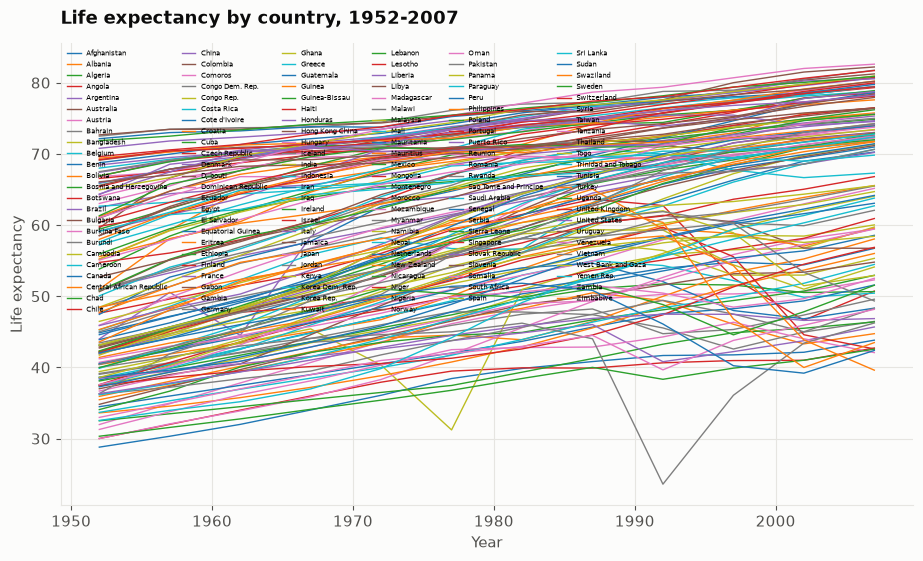

In [3]:
# DELIBERATELY BAD - one line per country, all 142, with a full legend.
fig, ax = plt.subplots(figsize=(11, 6))
for country, group in df.groupby("country"):
    ax.plot(group["year"], group["lifeExp"], linewidth=1, label=country)

ax.legend(ncol=6, fontsize=5, loc="upper left")
ax.set_title("Life expectancy by country, 1952-2007")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy")
plt.show()

**What is wrong with it:**

1. **142 lines on top of each other.** It is a plate of spaghetti. I cannot follow a single country from 1952 to
   2007 without losing it where the lines cross.
2. **The colours mean nothing.** Matplotlib only cycles through 10 colours, so every colour is reused about 14
   times. Even if I found a line I was curious about, I could not tell which country it is.
3. **The legend is useless.** 142 entries in 5pt text, and it sits on top of the data it is supposed to explain.
4. **No message.** The title just repeats the axis labels. After looking at it I only know "most lines go up".
5. **The interesting parts are hidden.** I can see a few lines crash in the 1990s, and one that drops to the
   20s, but the chart gives me no way to find out who they are or why.

The chart is technically correct, it is just trying to show everything, so it ends up showing nothing.

### 2a. Fix one - aggregate to continents

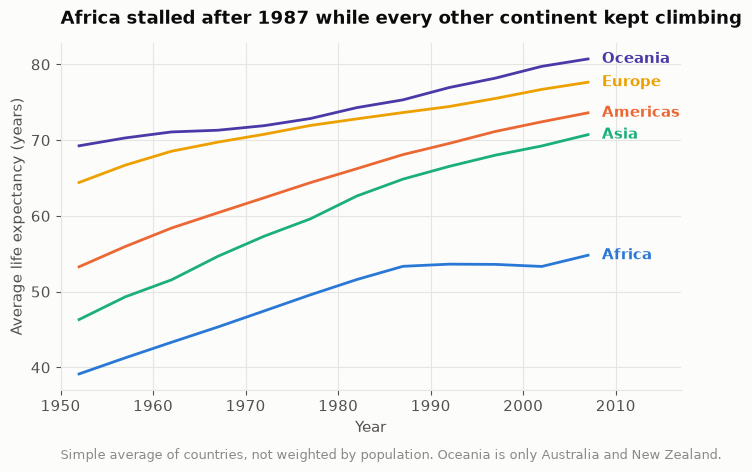

In [4]:
continents = df.groupby(["year", "continent"])["lifeExp"].mean().unstack()

fig, ax = plt.subplots()
for colour, name in zip([BLUE, ORANGE, AQUA, YELLOW, VIOLET], continents.columns):
    ax.plot(continents.index, continents[name], color=colour)
    ax.text(2008.5, continents[name].iloc[-1], name, color=colour, va="center", fontweight="bold")

ax.set_xlim(1950, 2017)
ax.set_title("Africa stalled after 1987 while every other continent kept climbing")
ax.set_xlabel("Year")
ax.set_ylabel("Average life expectancy (years)")
note(ax, "Simple average of countries, not weighted by population. Oceania is only Australia and New Zealand.")
plt.show()

**Why this chart:** year is an ordered scale, so a line chart. Five lines is few enough to follow, and I put the
continent names at the end of each line so the reader does not have to jump to a legend. Colour here means
continent and nothing else.

Every continent gains years until the late 1980s. After that Africa goes flat for twenty years
(53.3 in 1987, 54.8 in 2007), so the gap to the next continent grows to about 16 years.

### 2b. Fix two - keep all 142, highlight three

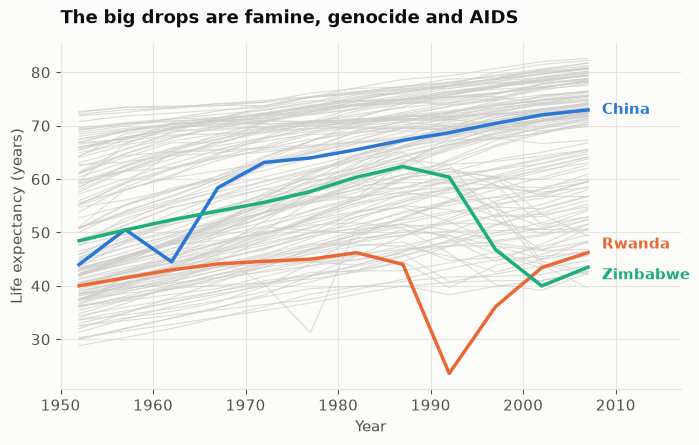

In [5]:
picks = {"China": BLUE, "Rwanda": ORANGE, "Zimbabwe": AQUA}
nudge = {"China": 0, "Rwanda": 1.5, "Zimbabwe": -1.5}  # stop the two end labels overlapping

fig, ax = plt.subplots()
for country, group in df.groupby("country"):
    ax.plot(group["year"], group["lifeExp"], color=QUIET, linewidth=0.8, alpha=0.7)

for country, colour in picks.items():
    group = df[df["country"] == country]
    ax.plot(group["year"], group["lifeExp"], color=colour, linewidth=2.5)
    ax.text(2008.5, group["lifeExp"].iloc[-1] + nudge[country], country,
            color=colour, va="center", fontweight="bold")

ax.set_xlim(1950, 2017)
ax.set_title("The big drops are famine, genocide and AIDS")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
plt.show()

**Why this chart:** still a line chart, because it is still a trend over time. The trick is that grey is also a
colour: the 141 other countries stay in the picture as a background, so you can see where the three sit
compared to everyone, but they don't compete for attention. The three countries are labelled directly and there is
no legend.

I picked three countries whose lines break the "everyone goes up" pattern:

- **China** drops from 50.5 to 44.5 between 1957 and 1962, the years of the Great Chinese Famine, then climbs
  faster than almost anyone to 73.
- **Rwanda** falls from 44 to 23.6 in 1992, the lowest point in the whole dataset, around the 1994 genocide.
- **Zimbabwe** goes from 62.4 in 1987 down to 40 in 2002, which is the HIV/AIDS epidemic.

## 3. Comparing (a) and (b)

The continent chart (a) is better for the **big picture**. It answers "which regions are ahead and are they
catching up?" in a few seconds, and it made the African slowdown obvious, which I could not see at all in the
spaghetti chart. What it cannot show is variation *inside* a continent. An average of 52 African countries
hides that some of them lost 20 years of life expectancy, and averages also smooth out sudden events. Rwanda's
crash is only a small dent in the Africa line.

The highlight chart (b) is better for **individual stories**. It keeps every country, so it shows the real
spread (in 2007 countries still range from about 40 to 83) and the sharp one-off crashes. What it cannot do is
summarise. From (b) I cannot tell you how Africa as a whole did compared to Asia, and it only works for the
three countries I chose. Someone else could pick three different countries and tell a different story.

So (a) answers "what happened overall?" and (b) answers "what happened to these particular countries?". A report
would probably need both.

## Watch out: `gdpPercap` is very skewed

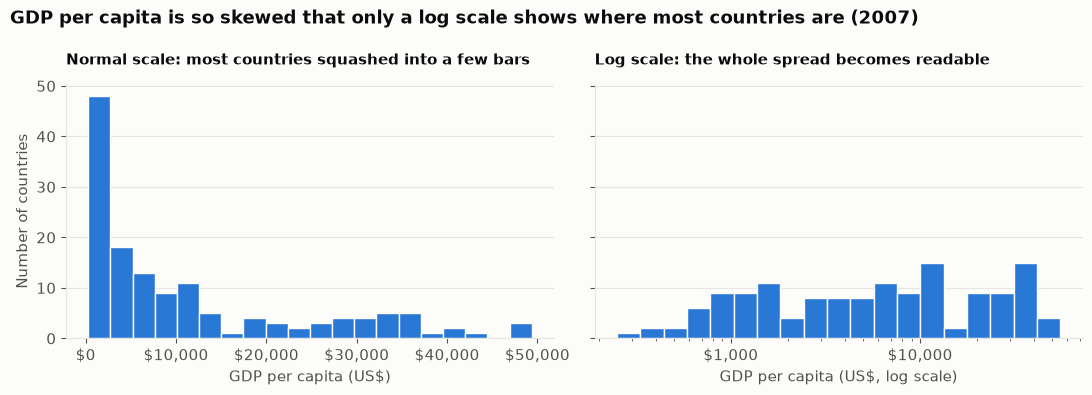

In [6]:
gdp_2007 = df.loc[df["year"] == 2007, "gdpPercap"]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
left.hist(gdp_2007, bins=20, color=BLUE, edgecolor=SURFACE)
left.set_title("Normal scale: most countries squashed into a few bars", fontsize=11)
left.set_xlabel("GDP per capita (US$)")
left.set_ylabel("Number of countries")

right.hist(gdp_2007, bins=np.logspace(np.log10(250), np.log10(55000), 20), color=BLUE, edgecolor=SURFACE)
right.set_xscale("log")
right.set_title("Log scale: the whole spread becomes readable", fontsize=11)
right.set_xlabel("GDP per capita (US$, log scale)")
for ax in (left, right):
    ax.xaxis.grid(False)
    ax.xaxis.set_major_formatter(lambda v, p: f"${v:,.0f}")

fig.suptitle("GDP per capita is so skewed that only a log scale shows where most countries are (2007)",
             x=0.01, ha="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

I used only 2007 here so each country is counted once (using all 1,704 rows would count every country 12
times).

**On the normal scale**, a handful of rich countries stretch the axis out to $50,000, so all the poorer
countries get squeezed into the first two or three bars. 40 of the 142 countries are under $2,000, but you
can't see any detail there. **On the log scale** every step on the axis is a multiplication (×10) instead of an
addition, so $500 → $1,000 takes the same space as $20,000 → $40,000. The data spreads out and you can actually see
that countries are spread from poor to rich fairly evenly, with no single "normal" income.

**My decision:** use a log scale for GDP. For money, ratios are what matter anyway: going from $500 to $1,000
changes a country much more than going from $40,000 to $40,500. The cost is that readers must be told the axis
is logarithmic, so I say it in the axis label and keep the tick labels in plain dollars.

## 4. Has the gap between the richest and poorest countries narrowed since 1952?

First I need to decide what "richest" and "poorest" means. The obvious answer, the single richest and
single poorest country each year, turns out to be misleading:

In [7]:
richest = df.loc[df.groupby("year")["gdpPercap"].idxmax(), ["year", "country", "gdpPercap"]]
extremes = df.groupby("year")["gdpPercap"].agg(["min", "max"])
richest["max / min"] = (extremes["max"] / extremes["min"]).round(0).values
richest.set_index("year")

,country,gdpPercap,max / min
year,,,
1952,Kuwait,108382.35290,363.0
1957,Kuwait,113523.13290,338.0
1962,Kuwait,95458.11176,269.0
1967,Kuwait,80894.88326,232.0
1972,Kuwait,109347.86700,306.0
1977,Kuwait,59265.47714,160.0
1982,Saudi Arabia,33693.17525,79.0
1987,Norway,31540.97480,82.0
1992,Kuwait,34932.91959,101.0


Kuwait is the richest country every year up to 1992, because it has a lot of oil and a small population. In the
1950s its GDP per capita was over $100,000, far above anyone else, and it then fell a long way. The max/min ratio
falls from 363× to 178×, which looks like "the gap narrowed", but that is really the story of one small country. So instead I compare the **10th percentile** country (poorer than
90% of the world) with the **90th percentile** country (richer than 90%). One outlier can't move those much.

In [8]:
gap = df.groupby("year")["gdpPercap"].quantile([0.1, 0.9]).unstack()
gap.columns = ["poorest_10pct", "richest_10pct"]
gap["ratio"] = gap["richest_10pct"] / gap["poorest_10pct"]
gap.round(1)

,poorest_10pct,richest_10pct,ratio
year,,,
1952,495.0,7255.3,14.7
1957,576.0,9667.9,16.8
1962,603.1,10967.2,18.2
1967,701.6,14060.6,20.0
1972,724.1,16606.2,22.9
1977,741.5,19091.7,25.7
1982,789.7,19467.7,24.7
1987,738.0,21866.5,29.6
1992,737.3,24752.2,33.6


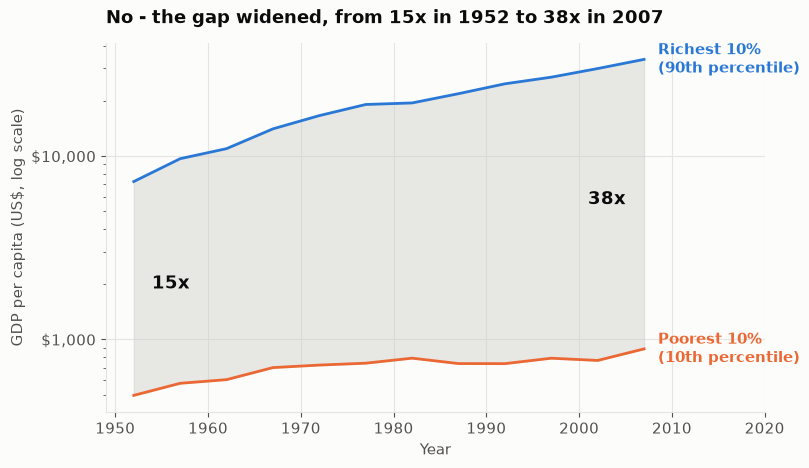

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.fill_between(gap.index, gap["poorest_10pct"], gap["richest_10pct"], color=QUIET, alpha=0.45)
ax.plot(gap.index, gap["richest_10pct"], color=BLUE)
ax.plot(gap.index, gap["poorest_10pct"], color=ORANGE)
ax.set_yscale("log")

ax.text(2008.5, gap["richest_10pct"].iloc[-1], "Richest 10%\n(90th percentile)", color=BLUE, va="center", fontweight="bold")
ax.text(2008.5, gap["poorest_10pct"].iloc[-1], "Poorest 10%\n(10th percentile)", color=ORANGE, va="center", fontweight="bold")
for year in (1952, 2007):
    middle = (gap.loc[year, "richest_10pct"] * gap.loc[year, "poorest_10pct"]) ** 0.5
    x = year + 4 if year == 1952 else year - 4   # keep the label inside the band
    ax.text(x, middle, f"{gap.loc[year, 'ratio']:.0f}x", ha="center", fontsize=13, fontweight="bold", color=INK)

ax.set_xlim(1949, 2020)
ax.yaxis.set_major_formatter(lambda v, p: f"${v:,.0f}")
ax.set_title("No - the gap widened, from 15x in 1952 to 38x in 2007")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita (US$, log scale)")
plt.show()

**Why this chart:** the question is about change over time, and years are ordered, so it is a line chart. I
used two lines for the two groups I am comparing, and shaded the space between them because that space *is*
the gap. The y-axis is on a log scale on purpose: on a log scale the vertical distance between two lines shows
their **ratio**, so if the band gets wider, the rich countries are pulling away in relative terms, not just in
dollars. On a normal scale the gap would look huge anyway, because $33,000 dwarfs $900, and it would
be hard to tell if the poorer countries were catching up proportionally. I did not use two y-axes. Both
lines are the same measure on the same axis.

**Answer:** the gap has not narrowed, it has more than doubled. In 1952 the 90th-percentile country was about
15× richer than the 10th-percentile one. By 2007 it was about 38× richer. The poorest countries did grow a
little (from about $500 to $890), but the rich ones grew from about $7,300 to $33,600. The band only gets
wider over the 55 years, apart from two small dips in 1982 and 2007.